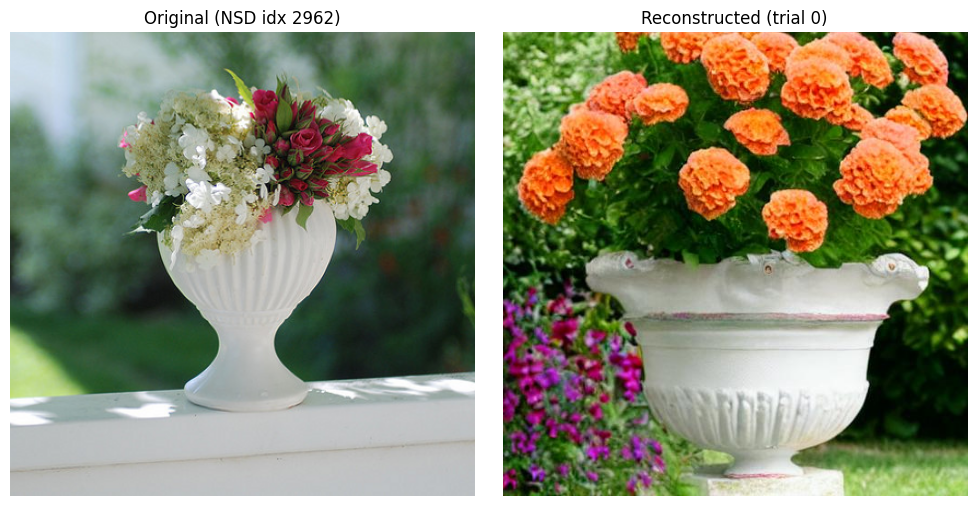

In [1]:
# --- Config ---
idx = 0  # trial / stimulus index you decoded
nsd_root = "data/nsddata"
processed_dir = "data/processed"
recon_dir = "./decoded"          # or ./reconstructions if you changed it
recon_prefix = ""               # e.g. "trial_" if you used --save_prefix

# ----------------

import h5py
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# Load NSD id mapping (same one used by create_pseudo_txt.py)
processed_dir = Path(processed_dir)
nsd_ids = np.load(processed_dir / "mappings" / "subj01_nsd_image_ids.npy")

# Load original NSD stimulus
stimuli_path = Path(nsd_root) / "stimuli" / "nsd" / "nsd_stimuli.hdf5"
with h5py.File(stimuli_path, "r") as f:
    nsd_idx = int(nsd_ids[idx])
    original = f["imgBrick"][nsd_idx]

original_img = Image.fromarray(original).convert("RGB")

# Load reconstructed image
recon_path = Path(recon_dir) / f"{recon_prefix}{idx}.jpg"
recon_img = Image.open(recon_path).convert("RGB")

# Plot side-by-side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title(f"Original (NSD idx {nsd_idx})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(recon_img)
plt.title(f"Reconstructed (trial {idx})")
plt.axis("off")

plt.tight_layout()
plt.show()
